In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
#1. Təsadüfi olaraq 50 tələbənin sınaq balları olan dataset yaradın (0–100 arası). Mean və variance hesablayın. 
# MoM ilə normal paylanmanın μ və σ parametrlərini təxmin edin.

In [51]:
data = np.random.randint(0, 100, size = 50)
print(f'Data mean: {data.mean()}')
print(f'Data variance: {data.var()}')
print(f'Data σ: {np.sqrt(data.var())}')

Data mean: 49.38
Data variance: 756.8356
Data σ: 27.510645212353708


In [52]:
#2. 100 ədəd təsadüfi hadisənin sayından ibarət dataset yaradın (Poisson paylanması üçün). Poisson paylanmasının λ parametrini MLE ilə təxmin edin. 
# Nümunə histogramı və Poisson ehtimal kütlə funksiyasını (PMF) qrafikdə müqayisə edin. 
# MLE və MoM nəticələrini müqayisə edin, hansının daha uyğun olduğunu şərh edin.

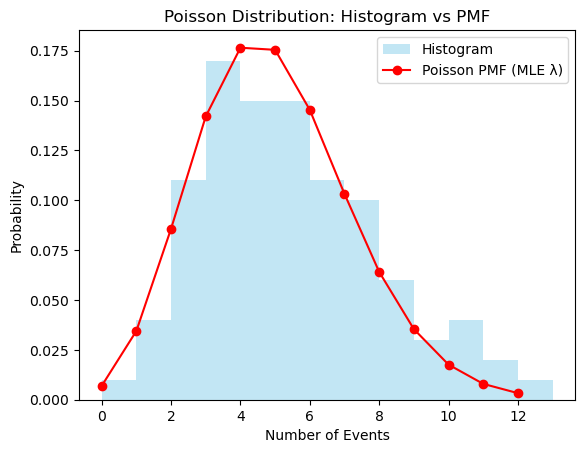

In [53]:
from scipy.stats import poisson
data = np.random.poisson(lam = 5, size = 100)
lambda_mle = data.mean()
plt.hist(data, bins=range(data.min(), data.max()+2), density=True, alpha=0.5, color='skyblue', label='Histogram')
x = np.arange(data.min(), data.max()+1)
plt.plot(x, poisson.pmf(x, mu=lambda_mle), 'o-', color='red', label='Poisson PMF (MLE λ)')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.title('Poisson Distribution: Histogram vs PMF')
plt.legend()
plt.show()

In [54]:
#3. 200 ədəd nümunədən ibarət dataset yaradın, məsələn tələbələrin gündəlik öyrənmə saatları. 
# Kernel Density Estimation (KDE) istifadə edərək ehtimal sıxlığını (PDF) təxmin edin.
# Histogram və KDE qrafiklərini eyni qrafikdə çəkərək müqayisə edin. Kernel genişliyini (bandwidth) dəyişdikdə qrafikin necə dəyişdiyini müşahidə edin.

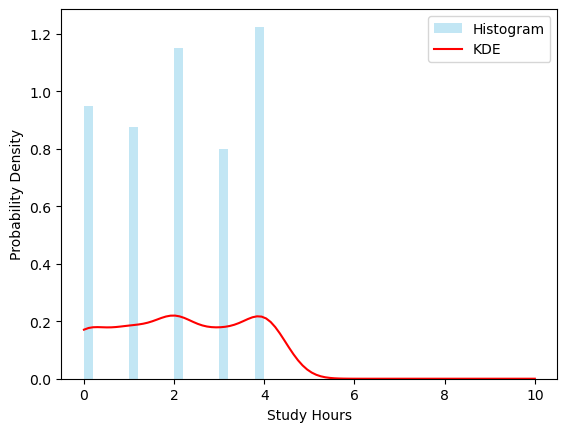

In [55]:
data = np.random.randint(0, 5, size = 200)
from scipy.stats import gaussian_kde
kde = gaussian_kde(data)
plt.hist(data, bins=20, density=True, alpha=0.5, color='skyblue', label='Histogram')
plt.plot(np.linspace(0, 10, 100), kde(np.linspace(0, 10, 100)), color='red', label='KDE')
plt.xlabel('Study Hours')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [56]:
#4. 1. Hər iki dəyişənin orta və dispersiyasıni tapin.
#data = {
#    "Gun": ["Bazar ertəsi", "Çərşənbə axşamı", "Çərşənbə", "Cümə axşamı", "Cümə", "Şənbə", "Bazar"] * 4,
#    "Satis": np.random.randint(100, 1000, 28),
#   "Musteri_sayi": np.random.randint(10, 100, 28)
#}

In [57]:
data = {
   "Gun": ["Bazar ertəsi", "Çərşənbə axşamı", "Çərşənbə", "Cümə axşamı", "Cümə", "Şənbə", "Bazar"] * 4,
   "Satis": np.random.randint(100, 1000, 28),
  "Musteri_sayi": np.random.randint(10, 100, 28)
}
df = pd.DataFrame(data)
print(f'Satis ortalama = {df['Satis'].mean()}, Variance: {df['Satis'].var()}')
print(f'Satis ortalama = {df['Musteri_sayi'].mean()}, Variance: {df['Musteri_sayi'].var()}')

Satis ortalama = 566.1428571428571, Variance: 67693.83068783069
Satis ortalama = 49.17857142857143, Variance: 897.3373015873016


In [58]:
#5. Satış və müştəri sayı arasında korrelyasiya tap.

In [59]:
correlation = df['Satis'].corr(df['Musteri_sayi'])
print(correlation)

-0.1468474476565722


In [60]:
#6. Satışların paylanmasını histogram və KDE ilə vizual göstər. 

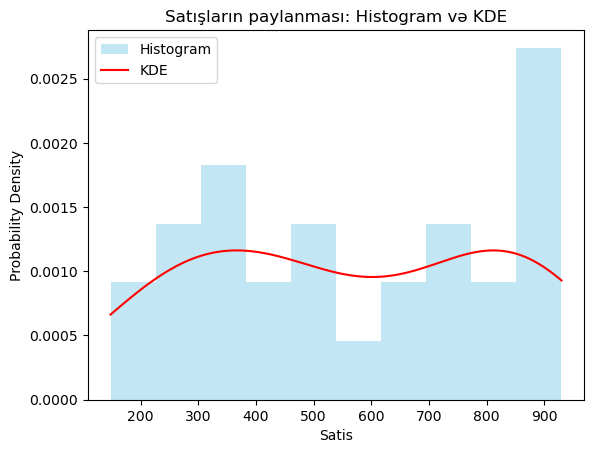

In [61]:
satis = df['Satis']
kde = gaussian_kde(satis)
x_grid = np.linspace(satis.min(), satis.max(), 200)
plt.hist(satis, bins=10, density=True, alpha=0.5, color='skyblue', label='Histogram')
plt.plot(x_grid, kde(x_grid), color='red', label='KDE')
plt.xlabel('Satis')
plt.ylabel('Probability Density')
plt.title('Satışların paylanması: Histogram və KDE')
plt.legend()
plt.show()

In [62]:
#7. Günləri satışa görə ən yaxşı və ən pis günləri tap

In [63]:
print(f'Best day: {df['Gun'][df['Satis'] == df['Satis'].max()]}')
print(f'Worst day: {df['Gun'][df['Satis'] == df['Satis'].min()]}')

Best day: 4               Cümə
8    Çərşənbə axşamı
Name: Gun, dtype: object
Worst day: 17    Cümə axşamı
Name: Gun, dtype: object
